## Analysis of Bayesian Factorization Machine Uncertainty

This notebook reads the out-of-fold (OOF) predictions from a trained Bayesian Factorization Machine (BFM) to perform a detailed uncertainty analysis. The training script was specifically designed to separate the two primary components of predictive uncertainty:

1.  **Epistemic Uncertainty** (or *Model Uncertainty*): This represents the model's uncertainty about its own parameters. It captures what the model *doesn't know* and can be reduced by providing more training data.
2.  **Aleatoric Uncertainty** (or *Data Uncertainty*): This represents the inherent, irreducible noise or randomness in the data itself (e.g., measurement error, biological variability). It cannot be reduced by collecting more data of the same kind.

Our goal is to quantify these uncertainties globally and then analyze how they behave as a function of the number of observations available for a given chemical.

In [2]:
import os
os.chdir('/home/tad/Desktop/Thesisfiles/ThesisCode/ecotox-toolkit/')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use a clean and professional plot style
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. Load Data and OOF Predictions ---
print("Loading data and prediction artifacts...")
ART = Path("artifacts")
DATA_DIR = Path("/home/tad/Desktop/Thesisfiles/ThesisCode/ecotox-toolkit/data_files")

# Reload the data in the exact same order used for training
# This import requires the dataloaders module to be accessible
from dataloaders.load_ecotox import load_ecotox_data
full_data, y_centered = load_ecotox_data(
    adore_path=DATA_DIR / "ecotox_mortality_processed.csv",
    chemicals_path=DATA_DIR / "ecotox_properties_with-oecd-function.csv",
    shuffle=True,
    random_state=42,
    use_selfies=False, use_mol2vec=False, use_fingerprint=False,
)

# Load the pre-computed OOF arrays
oof_mean = np.load(ART / "oof_mean.npy")
oof_epistemic_var = np.load(ART / "oof_epistemic_var.npy")
oof_aleatoric_var = np.load(ART / "oof_aleatoric_var.npy")

assert len(full_data) == oof_mean.size, "Data and prediction length mismatch!"

print(f"Loaded {len(full_data)} data points and corresponding predictions.")

Loading data and prediction artifacts...
Loaded 70670 data points and corresponding predictions.


In [4]:
# --- 2. Attach Predictions and Calculate Standard Deviations ---

# Create a fresh copy to avoid SettingWithCopyWarning
df = full_data.copy()

# Attach the mean prediction and the two sources of variance
df["pred_mean"] = oof_mean
df["epistemic_var"] = oof_epistemic_var
df["aleatoric_var"] = oof_aleatoric_var

# The total predictive variance is the sum of its components
df["total_var"] = df["epistemic_var"] + df["aleatoric_var"]

# Calculate standard deviations for easier interpretation (same units as target)
df["epistemic_sd"] = np.sqrt(df["epistemic_var"])
df["aleatoric_sd"] = np.sqrt(df["aleatoric_var"])
df["total_sd"] = np.sqrt(df["total_var"])

print("Uncertainty components attached to the dataframe:")
display(df[['CAS', 'species', 'pred_mean', 'epistemic_sd', 'aleatoric_sd', 'total_sd']].head())

Uncertainty components attached to the dataframe:


,CAS,species,pred_mean,epistemic_sd,aleatoric_sd,total_sd
0,552-89-6,Pimephales_promelas,1.294496,0.259612,0.494894,0.558855
1,2702-72-9,Eudiaptomus_gracilis,1.797461,0.318231,0.495973,0.589288
2,123-86-4,Menidia_beryllina,1.635938,0.371871,0.500879,0.623833
3,94-09-7,Ictalurus_punctatus,1.415815,0.119704,0.494894,0.509165
4,13171-21-6,Carassius_carassius,1.748148,0.359702,0.497985,0.614309


### Mathematical Background: The Law of Total Variance

The total predictive variance for a new data point $x_*$ given the training data $D$ is formally expressed by the Law of Total Variance. Let $\theta$ represent the model parameters (`w0`, `w`, `v`, `alpha`):

$$ \text{Var}(y_* | D) = \mathbb{E}_{p(\theta|D)}[\text{Var}(y_*|\theta)] + \text{Var}_{p(\theta|D)}[\mathbb{E}(y_*|\theta)] $$

This decomposes into:

$$ \underbrace{\text{Total Variance}}_{\texttt{total\_var}} = \underbrace{\text{Aleatoric Variance}}_{\texttt{aleatoric\_var}} + \underbrace{\text{Epistemic Variance}}_{\texttt{epistemic\_var}} $$

- **Aleatoric Variance**: `E[Var(y|θ)]`, is the expected value of the data noise variance (`1/alpha`) over the posterior. This is the noise we expect on average.
- **Epistemic Variance**: `Var(E[y|θ])`, is the variance of the mean prediction as we vary the parameters according to the posterior. This is precisely what we saved as `oof_epistemic_var`.

In [5]:
# --- 3. Global Average Uncertainty Metrics ---

# Calculate the average of each variance component across all predictions
avg_epistemic_var = df["epistemic_var"].mean()
avg_aleatoric_var = df["aleatoric_var"].mean()
avg_total_var = df["total_var"].mean()

print("="*50)
print("Global Average Uncertainty Analysis")
print("="*50)
print(f"Average Epistemic Variance (Model Uncertainty):   {avg_epistemic_var:.4f}")
print(f"Average Aleatoric Variance (Data Noise):          {avg_aleatoric_var:.4f}")
print(f"Average Total Predictive Variance:                {avg_total_var:.4f}")
print("-"*50)
# Also show the square root for interpretability
print(f"Avg. Model Standard Deviation:      {np.sqrt(avg_epistemic_var):.4f}")
print(f"Avg. Data Noise Standard Deviation:   {np.sqrt(avg_aleatoric_var):.4f}")
print(f"Avg. Total Standard Deviation:      {np.sqrt(avg_total_var):.4f}")
print("="*50)

Global Average Uncertainty Analysis
Average Epistemic Variance (Model Uncertainty):   0.0875
Average Aleatoric Variance (Data Noise):          0.2482
Average Total Predictive Variance:                0.3357
--------------------------------------------------
Avg. Model Standard Deviation:      0.2959
Avg. Data Noise Standard Deviation:   0.4982
Avg. Total Standard Deviation:      0.5794


## Uncertainty vs. Number of Observations

Now, we investigate the core question: how does the amount of data we have for a chemical affect the model's uncertainty? We will group the dataset by chemical (`CAS`) and plot the number of observations against each of the three types of uncertainty.

In [6]:
# --- 4. Group by Chemical to Analyze Per-Chemical Uncertainty ---

chem_summary = (
    df.groupby("CAS")
    .agg(
        n_obs=("CAS", "size"),
        avg_epistemic_sd=("epistemic_sd", "mean"),
        avg_aleatoric_sd=("aleatoric_sd", "mean"),
        avg_total_sd=("total_sd", "mean"),
    )
    .sort_values("n_obs", ascending=False)
)

print("Summary of uncertainty metrics per chemical (top 10 most observed):")
display(chem_summary.head(10))

Summary of uncertainty metrics per chemical (top 10 most observed):


/tmp/ipykernel_187990/4192814772.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("CAS")


,n_obs,avg_epistemic_sd,avg_aleatoric_sd,avg_total_sd
CAS,,,,
7758-98-7,2651,0.157168,0.498136,0.536233
10108-64-2,1865,0.170764,0.498161,0.540065
63-25-2,1161,0.140932,0.498100,0.523402
7733-02-0,1154,0.187371,0.498180,0.544491
7778-50-9,1145,0.133016,0.498147,0.525620
87-86-5,897,0.143138,0.498147,0.527078
115-29-7,879,0.184960,0.498113,0.542809
12125-02-9,852,0.143733,0.498130,0.528297
121-75-5,847,0.202857,0.498260,0.549923


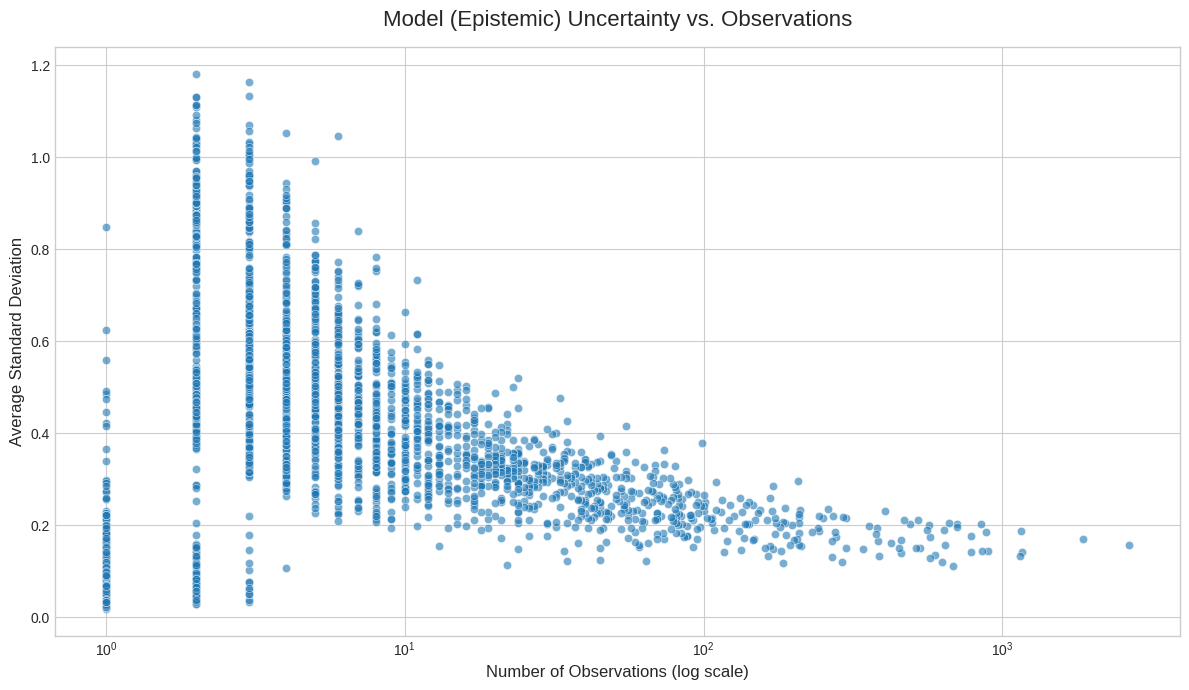

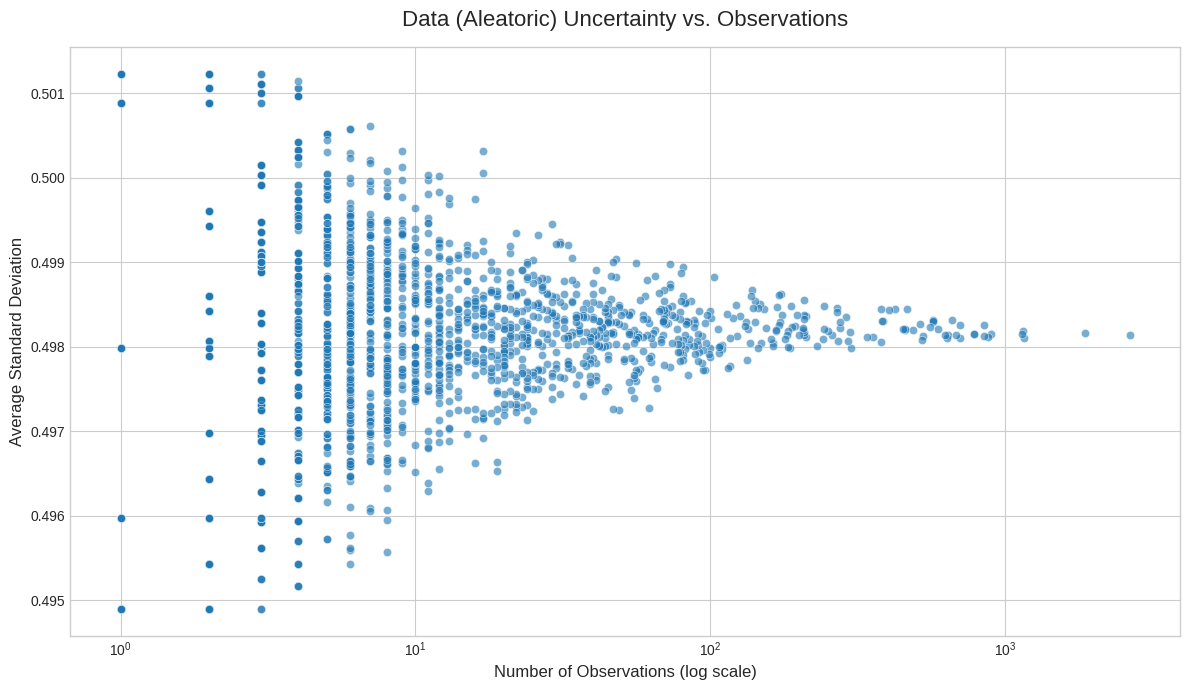

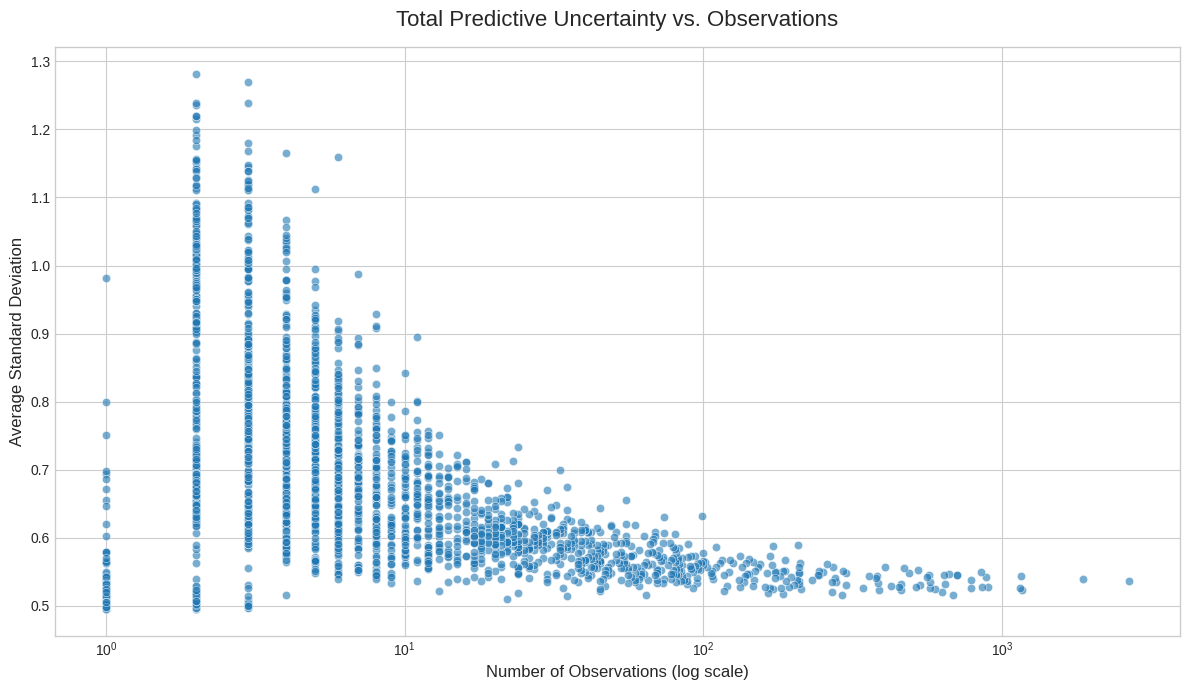

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_uncertainty_vs_obs(data, y_col, title):
    """Create a single scatter plot of uncertainty vs. n_obs."""
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.scatterplot(
        data=data,
        x="n_obs",
        y=y_col,
        alpha=0.6,
        ax=ax,
        edgecolor="white",
        linewidth=0.5
    )
    ax.set_xscale("log")
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel("Number of Observations (log scale)", fontsize=12)
    ax.set_ylabel("Average Standard Deviation", fontsize=12)
    fig.tight_layout()
    return fig, ax

# --- Plot 1: Epistemic Uncertainty ---
plot_uncertainty_vs_obs(
    chem_summary, "avg_epistemic_sd",
    "Model (Epistemic) Uncertainty vs. Observations"
)

# --- Plot 2: Aleatoric Uncertainty ---
plot_uncertainty_vs_obs(
    chem_summary, "avg_aleatoric_sd",
    "Data (Aleatoric) Uncertainty vs. Observations"
)

# --- Plot 3: Total Uncertainty ---
plot_uncertainty_vs_obs(
    chem_summary, "avg_total_sd",
    "Total Predictive Uncertainty vs. Observations"
)

plt.show()  # optional; in notebooks, each figure will usually display automatically


In [10]:
for column in full_data.columns:
    print(column)

test_id
reference_number
CAS
test_location
test_exposure_type
test_control_type
test_media_type
test_application_freq_unit
test_organism_lifestage
result_id
result_effect
result_endpoint
duration
result_conc1_type
result_conc1_mean_op
result_conc1_mean
result_conc1_mean_mol
media_ph_mean
media_temperature_mean
tax_all
tax_name
tax_class
tax_order
tax_family
tax_genus
tax_species
species
species_number
tax_group
tax_pdm_available
tax_eco_climate
tax_eco_ecozone
tax_eco_food
tax_eco_migrate5
tax_eco_migrate2
tax_ps_ampv
tax_ps_ampkap
tax_ps_amppm
tax_lh_amd
tax_lh_lbcm
tax_lh_lpcm
tax_lh_licm
tax_lh_ri#/d
result_conc1_mean_binary
result_conc1_mean_log
conc
chem_dtxsid
chem_name
test_cas_name
chem_sf
chem_mw
chem_mp
chem_ws
chem_ws_binary
chem_dtxcid
chem_inchi
chem_inchikey
chem_pcp_cid
chem_pcp_inchikey
chem_pcp_inchi
chem_pcp_iupac_name
chem_pcp_can_smiles
chem_pcp_fp
chem_pcp_heavy_atom_count
chem_rdkit_clogp
chem_pcp_bonds_count
chem_pcp_doublebonds_count
chem_pcp_triplebonds_count
c